# Notebook to define and evaluate a baseline Siamese UNet

Note that UNet baseline uses early fusion whereas Siamese uses late fusion via feature differencing. In other words, these two architectures differ in how input data is fused, and evaluation of these architectures must consider these differences.

In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [2]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from  src.model_siamese import SiameseUNet

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [4]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 8
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 12
BASE_FEATURES = 32
SAVE_PATH = "best_siamese_unet_combo.pth"

In [5]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=True, augment_train=True)

In [7]:
# Sanity check
pre, post, masks = next(iter(train_loader))

print(f"Pre image:  {pre.shape}")    # [B, 3, H, W]
print(f"Post image: {post.shape}")   # [B, 3, H, W]
print(f"Masks:      {masks.shape}")  # [B, H, W]
print(f"Mask range: {masks.min()} – {masks.max()}")
print(f"Device:     {pre.device}")

Pre image:  torch.Size([8, 3, 512, 512])
Post image: torch.Size([8, 3, 512, 512])
Masks:      torch.Size([8, 512, 512])
Mask range: 0 – 4
Device:     cpu


In [8]:
# Loss — ComboLoss (CE + Tversky)
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)

In [9]:
# Model
model = SiameseUNet(
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES,
    in_channels=3 # only include 3 channels for Siamese
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device)

Model parameters: 9,070,821
cuda:0


In [10]:
# Loss, Optimizer, LR Scheduler (Define Here)
# Heavily penalize FN damage pixels with heavily weighted tversky loss and tversky_alpha
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.8,
                      tversky_beta=0.2, num_classes=NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

In [11]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True,
    siamese = True)



Epoch 1/50  (lr=1.00e-04)
  Train Loss: 0.8101  |  Val Loss: 0.6624
  Train mIoU: 0.2598  |  Val mIoU: 0.2554
  Train Acc:  0.8478  |  Val Acc:  0.8937
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8906   0.9943   0.8952
    Minor             0.2925   0.3033   0.8913
    Major             0.0006   0.0006   0.0143
    Destroyed         0.0022   0.0027   0.0127
    Unclassified      0.0912   0.1187   0.2830
  *** Saved new best model (mIoU=0.2554) ***



Epoch 2/50  (lr=9.05e-05)
  Train Loss: 0.6018  |  Val Loss: 0.5836
  Train mIoU: 0.3518  |  Val mIoU: 0.3243
  Train Acc:  0.9220  |  Val Acc:  0.9343
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9402   0.9921   0.9473
    Minor             0.3578   0.4271   0.6878
    Major             0.0017   0.0017   0.2051
    Destroyed         0.0175   0.0200   0.1255
    Unclassified      0.3044   0.4788   0.4552
  *** Saved new best model (mIoU=0.3243) ***



Epoch 3/50  (lr=6.58e-05)
  Train Loss: 0.5353  |  Val Loss: 0.5315
  Train mIoU: 0.4012  |  Val mIoU: 0.3492
  Train Acc:  0.9342  |  Val Acc:  0.9545
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9557   0.9925   0.9626
    Minor             0.4708   0.5269   0.8155
    Major             0.0017   0.0018   0.0508
    Destroyed         0.0145   0.0158   0.1505
    Unclassified      0.3035   0.6128   0.3755
  *** Saved new best model (mIoU=0.3492) ***



Epoch 4/50  (lr=3.52e-05)
  Train Loss: 0.5020  |  Val Loss: 0.5131
  Train mIoU: 0.4331  |  Val mIoU: 0.3692
  Train Acc:  0.9394  |  Val Acc:  0.9533
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9560   0.9924   0.9630
    Minor             0.4577   0.5295   0.7716
    Major             0.0034   0.0035   0.1745
    Destroyed         0.0234   0.0245   0.3283
    Unclassified      0.4056   0.6006   0.5554
  *** Saved new best model (mIoU=0.3692) ***



Epoch 5/50  (lr=1.05e-05)
  Train Loss: 0.4788  |  Val Loss: 0.5140
  Train mIoU: 0.4567  |  Val mIoU: 0.3695
  Train Acc:  0.9429  |  Val Acc:  0.9539
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9581   0.9929   0.9647
    Minor             0.4604   0.5441   0.7496
    Major             0.0028   0.0028   0.1916
    Destroyed         0.0225   0.0233   0.3763
    Unclassified      0.4040   0.5824   0.5687
  *** Saved new best model (mIoU=0.3695) ***


...


Epoch 23/50  (lr=7.30e-05)
  Train Loss: 0.4159  |  Val Loss: 0.4873
  Train mIoU: 0.5165  |  Val mIoU: 0.3995
  Train Acc:  0.9514  |  Val Acc:  0.9679
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9684   0.9921   0.9759
    Minor             0.5593   0.6350   0.8243
    Major             0.0046   0.0050   0.0642
    Destroyed         0.0444   0.0479   0.3777
    Unclassified      0.4208   0.6847   0.5219



Epoch 24/50  (lr=6.58e-05)
  Train Loss: 0.4106  |  Val Loss: 0.4731
  Train mIoU: 0.5217  |  Val mIoU: 0.3839
  Train Acc:  0.9522  |  Val Acc:  0.9659
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9660   0.9924   0.9732
    Minor             0.5540   0.6237   0.8323
    Major             0.0032   0.0035   0.0425
    Destroyed         0.0106   0.0116   0.1056
    Unclassified      0.3856   0.4735   0.6751



Epoch 25/50  (lr=5.82e-05)
  Train Loss: 0.4068  |  Val Loss: 0.4667
  Train mIoU: 0.5250  |  Val mIoU: 0.3973
  Train Acc:  0.9526  |  Val Acc:  0.9650
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9645   0.9932   0.9709
    Minor             0.5450   0.5998   0.8562
    Major             0.0041   0.0045   0.0422
    Destroyed         0.0112   0.0167   0.0327
    Unclassified      0.4619   0.5544   0.7346



Epoch 26/50  (lr=5.05e-05)
  Train Loss: 0.4026  |  Val Loss: 0.4923
  Train mIoU: 0.5309  |  Val mIoU: 0.3965
  Train Acc:  0.9532  |  Val Acc:  0.9656
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9662   0.9930   0.9728
    Minor             0.5460   0.6098   0.8393
    Major             0.0050   0.0052   0.0940
    Destroyed         0.0466   0.0534   0.2684
    Unclassified      0.4189   0.7097   0.5055



Epoch 27/50  (lr=4.28e-05)
  Train Loss: 0.3997  |  Val Loss: 0.5125
  Train mIoU: 0.5362  |  Val mIoU: 0.3638
  Train Acc:  0.9540  |  Val Acc:  0.9618
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9630   0.9938   0.9688
    Minor             0.5267   0.5824   0.8463
    Major             0.0062   0.0064   0.1689
    Destroyed         0.0392   0.0415   0.4097
    Unclassified      0.2842   0.6727   0.3298

Early stopping triggered after 27 epochs.


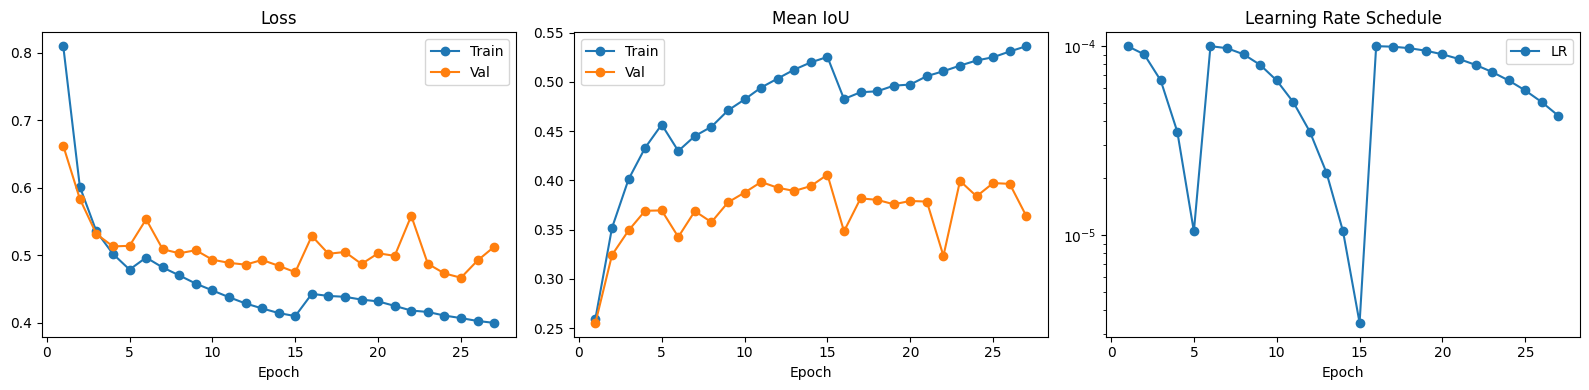

In [12]:
plot_train_history(history)

In [13]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=True)

Test Loss: 0.8862
Test mIoU: 0.3020
Test Acc:  0.9073

Class                IoU     Prec   Recall
No Damage         0.9276   0.9723   0.9527
Minor             0.5473   0.6091   0.8437
Major             0.0162   0.1055   0.0188
Destroyed         0.0110   0.2477   0.0114
Unclassified      0.0077   0.0178   0.0134


In [14]:
print("a")

a
